### Exercises

#### Exercise 1

##### Part 1

Read in the dataset in `fuel.csv`. Inspect the distribution of the response variable `fuel_consumption`.

<Axes: xlabel='fuel_consumption', ylabel='Count'>

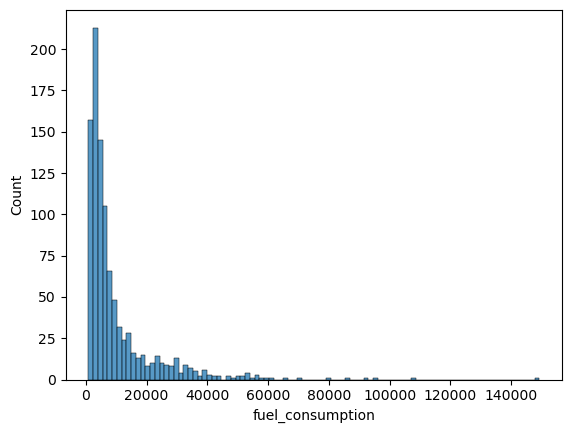

In [14]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv("../data/fuel.csv")
df.head()
sns.histplot(data=df, x="fuel_consumption")


##### Part 2

Determine whether a transformation should be applied to the response to make its distribution appear more normal. Apply that transformation and then inspect the distribution of the transformed response variable.

<Axes: xlabel='log_fuel', ylabel='Count'>

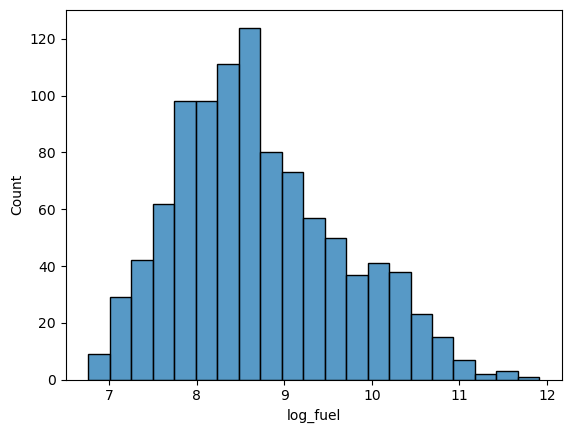

In [16]:
# YOUR CODE HERE
df["log_fuel"] = np.log(df["fuel_consumption"])
sns.histplot(data=df, x = "log_fuel")

#### Exercise 2

##### Part 1

Select a quantitative predictor that you believe would be useful in modeling the response variable. Provide a numeric summary or visualization to justify this choice.

<Axes: xlabel='log_fuel', ylabel='flight_distance'>

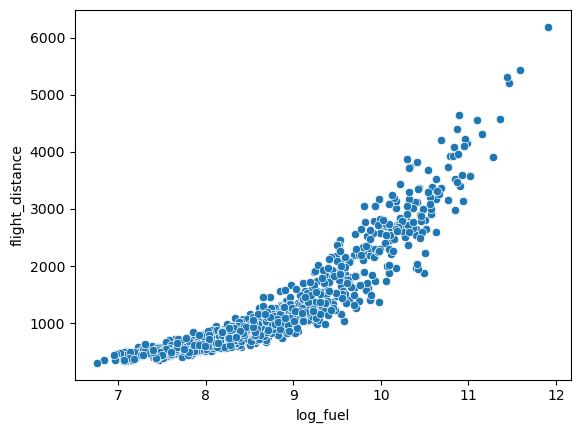

In [22]:
# YOUR CODE HERE
sns.scatterplot(data=df, x="log_fuel", y="flight_distance")


##### Part 2

Determine if a transformation should be applied to the predictor to achieve a more linear relationship between the response and the predictor. If a transformation is necessary, apply the transformation and provide another summary or visualization to demonstrate the effect of this transformation.

<Axes: xlabel='log_fuel', ylabel='log_flight_distance'>

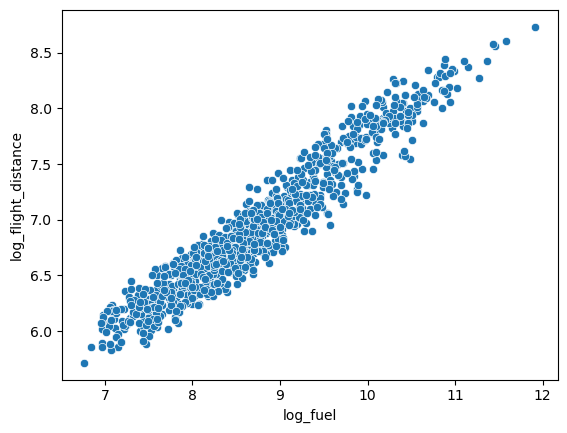

In [23]:
# YOUR CODE HERE
df["log_flight_distance"] = np.log(df["flight_distance"])
sns.scatterplot(data=df, x="log_fuel", y="log_flight_distance")

#### Exercise 3

##### Part 1

Use the `sklearn` library to fit a simple linear regression model using your predictor and response variable. Output the intercept and slope of the fitted model.

In [39]:
# YOUR CODE HERE
from sklearn.linear_model import LinearRegression

slr_model = LinearRegression()
X_slr = df[["log_flight_distance"]]
y = df["log_fuel"]
slr_model.fit(X_slr,y)

print("Intercept:", slr_model.intercept_)
print("Slope:", slr_model.coef_[0])

Intercept: -2.001427439528781
Slope: 1.547625402299192


##### Part 2

Write out the regression equation for the fitted model and interpret the intercept and slope in context.

log(fuel)^ = -2 + 1.547.log(distance)
This means that when the log of flight distance is zero, we would expect the log of fuel consumption to be -2. For every one unit increase in the log of flight distance, there is an increase of 1.548 in the log of fuel consumption.

#### Exercise 4

##### Part 1

Investigate relationships with other quantitative variables and the response. Identify several other quantitative variables you could include in your model. Provide a numeric summary or visualization justifying these choices.

<Axes: xlabel='seats_installed', ylabel='log_fuel'>

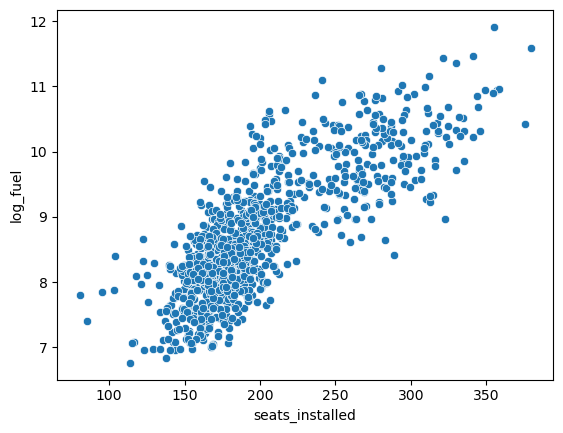

In [26]:
# YOUR CODE HERE
sns.scatterplot(data=df, x="seats_installed", y="log_fuel")

<Axes: xlabel='log_holding_time', ylabel='log_fuel'>

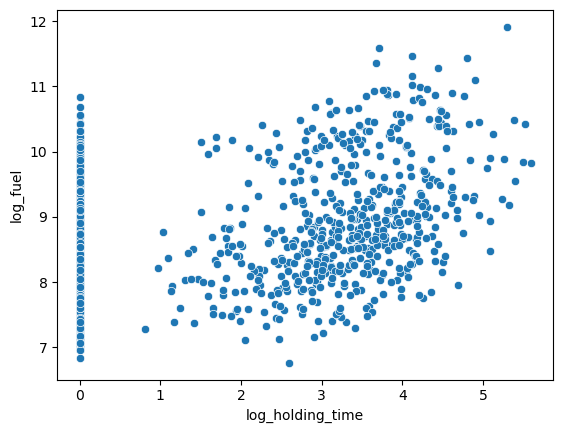

In [30]:
df["log_holding_time"] = np.log(df["holding_time"]+1)
sns.scatterplot(data=df, x="log_holding_time", y="log_fuel")

<Axes: xlabel='log_checked_baggage', ylabel='log_fuel'>

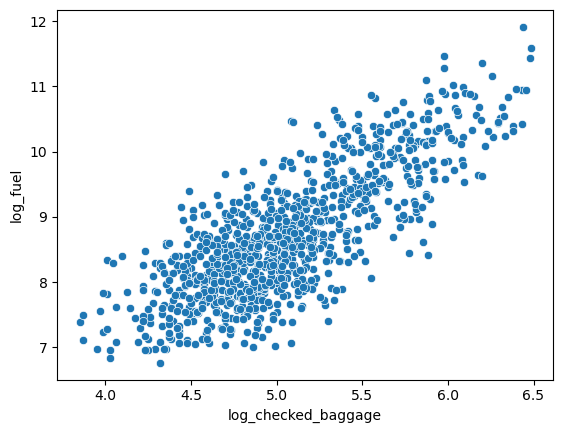

In [37]:
df["log_checked_baggage"] = np.log(df["checked_baggage_count"])
sns.scatterplot(data=df, x="log_checked_baggage", y="log_fuel")

##### Part 2

Use the `sklearn` library to fit a multiple linear regression model with the other selected quantitative variables. Output the intercept and slope coefficients.

In [40]:
# YOUR CODE HERE
mlr_model = LinearRegression()

X_mlr = df[["log_holding_time", "seats_installed", "log_checked_baggage"]]

mlr_model.fit(X_mlr, y)

print("Intercept: ", mlr_model.intercept_)
print("Slope: ", mlr_model.coef_)

Intercept:  2.8845468960662863
Slope:  [0.1731418  0.00864264 0.7468049 ]


##### Part 3

Write out the full regression equation for your model. Interpret each of the coefficients for your fitted model in context.


log_fuel = 2.885 + 0.173(log holding time) + 0.009(seats installed) + 0.747(log checked baggage)
Assume we want to interpret the meaning of the coefficient for log holding time. We would say that a one unit increase in log holding time results in a increase of  in log fuel, while holding seat installed, and log checked baggage.

#### Exercise 5

##### Part 1

Identify one or more categorical variables that could be useful in predicting the response variable. Provide a numeric summary or visualization to justify these choices of categorical variables.

<Axes: xlabel='aircraft_type', ylabel='log_fuel'>

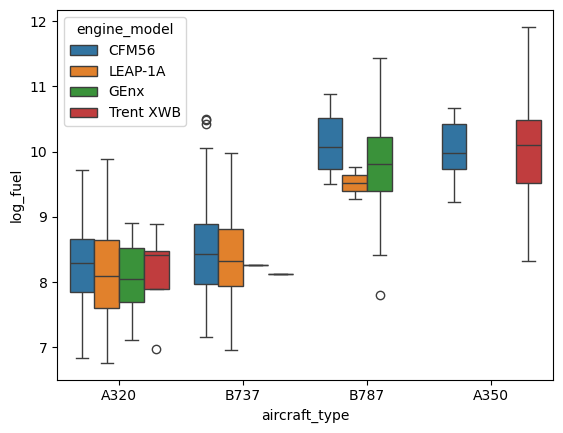

In [42]:
# YOUR CODE HERE
sns.boxplot(data=df, x="aircraft_type", y="log_fuel", hue="engine_model")

##### Part 2

Use the `sklearn` library to fit a multiple linear regression model including the selected categorical variables and any relevant quantitative variables. Output the intercept and slope coefficients.

In [52]:
# YOUR CODE HERE
df = pd.get_dummies(data=df, columns=["aircraft_type"], drop_first=True, dtype="int")
X_cat = df[["log_flight_distance", "log_holding_time", "seats_installed", "log_checked_baggage", 
            "aircraft_type_A350", "aircraft_type_B737", "aircraft_type_B787"]]

cat_model = LinearRegression()
cat_model.fit(X_cat, y)
print("Intercept:", cat_model.intercept_)
print("Slope:", cat_model.coef_)

Intercept: -2.2302716661464217
Slope: [ 1.39838103  0.10043777  0.00163244  0.1531183  -0.24122162  0.05770461
 -0.1839628 ]


##### Part 3

Write out the full regression equation for your model. Interpret each of the coefficients for your fitted model in context.

log(fuel) = −2.23 + 1.398xlog_flight_distance + 0.100xlog_holding_time + 0.0016xseats_installed + 0.153xlog_checked_baggage − 0.241xaircraft_type_A350 + 0.058xaircraft_type_B737 − 0.184xaircraft_type_B787

Assume we want to interpret the meaning of the coefficient for log_flight_distance. A one unit increase in log_flight_distance results in an increase of 1.398 in log_fuel, while holding log_holding_time, seats_installed, log_checked_baggage, aircraft_type_A350, aircraft_type_B737, and aircraft_type_B787 constant.

#### Exercise 6

Part 1
Compute RMSE and for all of the previously fitted models.

In [55]:
# YOUR CODE HERE
from sklearn.metrics import root_mean_squared_error, r2_score

slr_preds = slr_model.predict(X_slr)
mlr_preds = mlr_model.predict(X_mlr)
cat_preds = cat_model.predict(X_cat)

print("SLR RMSE: ", root_mean_squared_error(slr_preds, y))
print("MLR RMSE: ", root_mean_squared_error(mlr_preds, y))
print("Cat RMSE: ", root_mean_squared_error(cat_preds, y))

SLR RMSE:  0.26518768716154173
MLR RMSE:  0.43055139488468147
Cat RMSE:  0.18900120342949062


In [56]:
print("SLR R2: ", r2_score(slr_preds, y))
print("MLR R2: ", r2_score(mlr_preds, y))
print("Cat R2: ", r2_score(cat_preds, y))

SLR R2:  0.9147964997898248
MLR R2:  0.739027189581813
Cat R2:  0.9584621777537498


##### Part 2

Keeping in mind that we want to find models that have high predictive power, but are relatively simple, which of the competing models would you select?

The best model is categorical model, because it comes with lowest prediction error and highest explanatory power includes both numeric and categorical effects.

#### Exercise 7

##### Part 1

Produce a numeric summary or visualization that allows you to investigate any instances of multicollinearity.

<Axes: >

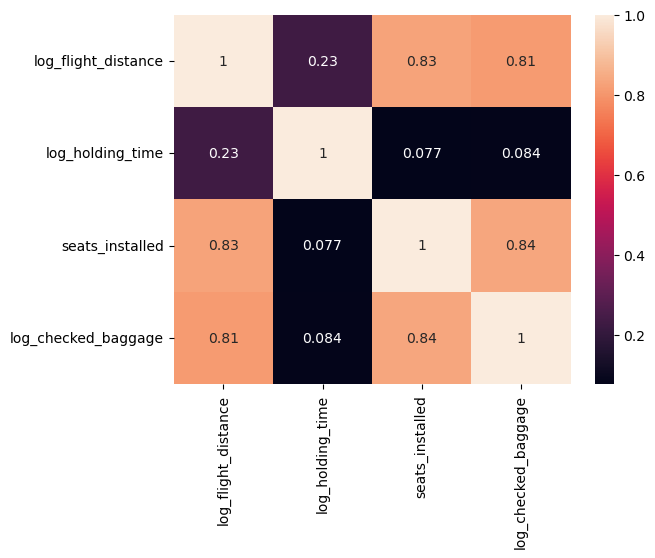

In [57]:
# YOUR CODE HERE
corr_matrix = df[[
    "log_flight_distance",
    "log_holding_time",
    "seats_installed",
    "log_checked_baggage"
]].corr()

sns.heatmap(corr_matrix, annot=True)

##### Part 2

Describe any instances of multicollinearity that you discovered.

long_flight_distance with seats_installed is strongly correlated at 0.83 
long_flight_distance is also strongly related to log_checked_baggage with a correlation of 0.81.
seats_installed and log_checked_baggage is strongly correlated with a correlation of 0.84.

#### Exercise 8


##### Part 1

Create a plot of the fitted values $\hat{y}_i$ versus the residuals $y_i - \hat{y}_i$.

Text(0, 0.5, 'Residuals')

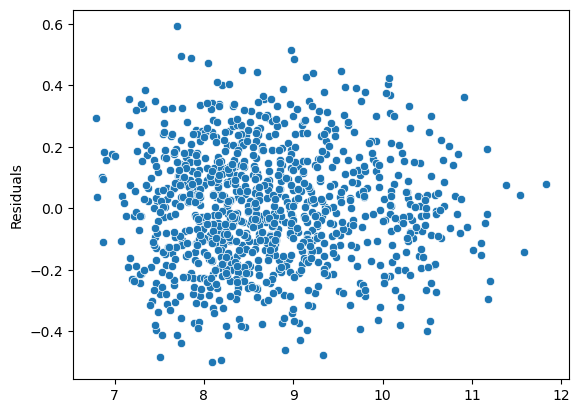

In [58]:
# YOUR CODE HERE
resids = y - cat_preds

sns.scatterplot(x = cat_preds, y = resids).set_ylabel("Residuals")

##### Part 2

Using the plot of fitted values versus residuals, do there appear to be any violations of the assumption of linearity?

No violations of linearity. The scatterplot looks good with the residuals appear to be randomly scattered.

#### Exercise 9

##### Part 1

Plot the residuals $y_i-\hat{y}_i$ against other potentially useful predictors that haven't already been included in the model.

Text(0, 0.5, 'Residuals')

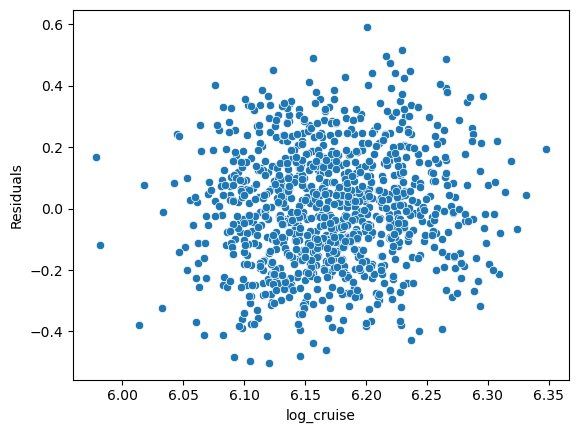

In [72]:
# YOUR CODE HERE
#sns.scatterplot(data=df, x="takeoff_weight", y=resids).set_ylabel("Residuals")
#sns.scatterplot(data=df, x="payload_weight", y=resids).set_ylabel("Residuals")
df["log_cruise"] = np.log(df["average_cruise_speed"])
df["log_payload"] = np.log(df["payload_weight"])
sns.scatterplot(data=df, x="log_cruise", y=resids).set_ylabel("Residuals")


##### Part 2

Based on the plots of residuals versus other predictors, do their appear to be any other predictors that should be included in the model?

Based on the plots of residuals versus log_cruise, there do not appear to be any other predictors that should be included in the model because log_cruise does not explain any remaining variation in log_fuel. The residuals are randomly scattered around zero, which means the categorical model does not need to add log_cruise to improve predictive performance.


#### Exercise 10

##### Part 1

Using everything you've learned so far, fit a final model that you would use to predict the response. Report the intercept and coefficients for this final model.

In [74]:
# YOUR CODE HERE
print("Intercept:", cat_model.intercept_)
print("Coef: ", cat_model.coef_)

Intercept: -2.2302716661464217
Coef:  [ 1.39838103  0.10043777  0.00163244  0.1531183  -0.24122162  0.05770461
 -0.1839628 ]


##### Part 2

Report the regression equation for your final model.

log(fuel) = −2.23 + 1.398xlog_flight_distance + 0.100xlog_holding_time + 0.0016xseats_installed + 0.153xlog_checked_baggage − 0.241xaircraft_type_A350 + 0.058xaircraft_type_B737 − 0.184xaircraft_type_B787

This final model was selected because it had the strongest predictive performance, with high explanatory power and low prediction error while remaining relatively simple and interpretable.